# 08. 리뷰 데이터 EDA 그래프 (2026-10-07)

**목적**: 1차 발표 "데이터: Amazon Reviews" 슬라이드에 넣을 탐색 그래프를 만든다.

**입력**
- `data/processed/weekly_reviews/weekly_reviews.csv`: 품목 × 주 리뷰 수·평점 (02 노트북 결과)
- `data/processed/weekly_purchase/weekly_purchase.csv`: 품목 × 주 구매 (B 결과)
- 텍스트 정리 통계: 03 노트북 출력값을 옮겨 적음 (`reviews_text.parquet`는 용량 때문에 저장소에 없음)

**출력**: `figures/eda_*.png` 5개

## 1. 준비

- 색: 한 그래프에 계열이 하나면 파랑 하나만 쓴다. 두 계열이면 파랑·주황 (06 그림과 같은 색).
- 회색 띠: 화장지 임시 급증 구간 2020-03-08 ~ 04-04. 서연님 spike 결과가 나오면 바꾼다.
- 한글 글꼴: 맑은 고딕 → 애플고딕 → 나눔고딕 순으로 있는 것을 쓴다.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if any(f == x.name for x in font_manager.fontManager.ttflist):
        plt.rcParams["font.family"] = f; break
plt.rcParams.update({"axes.unicode_minus": False, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#9a9a9a", "axes.labelcolor": "#444444", "xtick.color": "#555555",
                     "ytick.color": "#555555", "axes.grid": True, "grid.color": "#e6e6e6", "grid.linewidth": 0.8,
                     "axes.axisbelow": True, "figure.dpi": 110, "savefig.dpi": 200})
BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#d9d9d9"
SPIKE = (pd.Timestamp("2020-03-08"), pd.Timestamp("2020-04-04"))
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
KO = {"TOILET_PAPER": "화장지", "SURFACE_CLEANING_WIPE": "소독 물티슈", "PUZZLES": "퍼즐",
      "BAKING_PAN": "베이킹 팬", "BLANKET": "담요", "DRINKING_CUP": "텀블러·컵"}
ORDER = ["TOILET_PAPER", "SURFACE_CLEANING_WIPE", "PUZZLES", "BAKING_PAN", "BLANKET", "DRINKING_CUP"]

rv = pd.read_csv("../data/processed/weekly_reviews/weekly_reviews.csv", parse_dates=["week"])
pu = pd.read_csv("../data/processed/weekly_purchase/weekly_purchase.csv", parse_dates=["week"])
print(rv.shape, pu.shape, rv["week"].min().date(), "~", rv["week"].max().date())

(1566, 7) (1566, 5) 2017-12-31 ~ 2022-12-25


## 2. 품목별 주간 리뷰 수 (2018~2022)

- 품목마다 리뷰 수 규모가 달라서 **칸마다 세로축을 따로** 둔다. 모양(언제 늘었나)을 비교하는 그림이다.
- 보는 점: 화장지·물티슈는 2020년 3월에 튀고, 담요는 매년 겨울에 오르는 계절형인지.

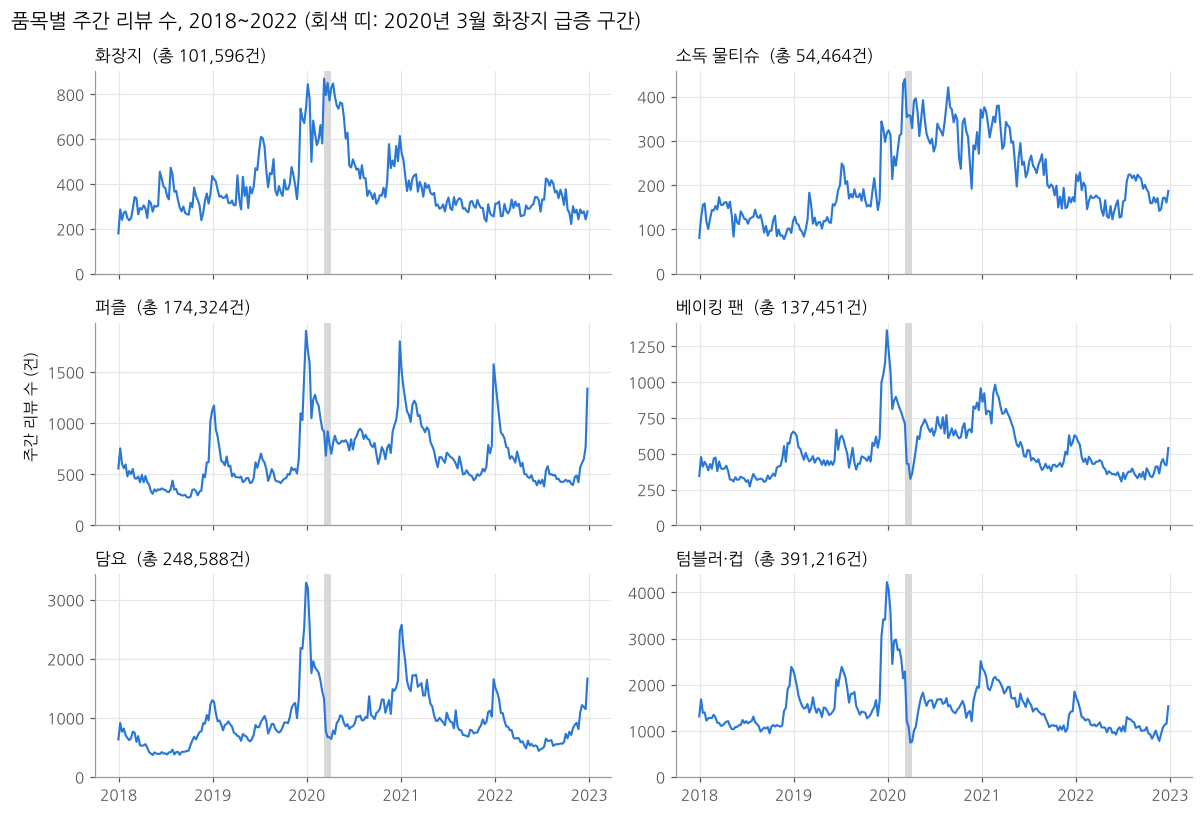

품목별 리뷰가 가장 많았던 주
         product_type       week  review_count
           BAKING_PAN 2019-12-29          1361
              BLANKET 2019-12-29          3288
         DRINKING_CUP 2019-12-29          4222
              PUZZLES 2019-12-29          1902
SURFACE_CLEANING_WIPE 2020-03-08           440
         TOILET_PAPER 2020-03-08           870


In [2]:
fig, axes = plt.subplots(3, 2, figsize=(11, 7.5), sharex=True)
for ax, pt in zip(axes.flat, ORDER):
    d = rv[rv["product_type"] == pt]
    ax.axvspan(*SPIKE, color=GRAY, lw=0)
    ax.plot(d["week"], d["review_count"], color=BLUE, lw=1.4)
    ax.set_title(f"{KO[pt]}  (총 {d['review_count'].sum():,}건)", loc="left", fontsize=11)
    ax.set_ylim(0, None)
    ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("품목별 주간 리뷰 수, 2018~2022 (회색 띠: 2020년 3월 화장지 급증 구간)", x=0.01, ha="left", fontsize=13)
fig.supylabel("주간 리뷰 수 (건)", fontsize=10)
fig.tight_layout()
fig.savefig(FIG / "eda_weekly_reviews_by_type.png", bbox_inches="tight"); plt.show()

peak = rv.loc[rv.groupby("product_type")["review_count"].idxmax(), ["product_type", "week", "review_count"]]
print("품목별 리뷰가 가장 많았던 주"); print(peak.to_string(index=False))

## 3. 화장지: 리뷰 수와 구매율이 같이 움직이나

- 리뷰 수(건)와 구매율(활동 응답자 1,000명당 구매)은 단위가 달라서 **세로축 두 개를 쓰지 않고**, 둘 다 **2019년 평균 = 100**으로 바꿔 한 축에 그린다.
- 구매는 주당 10~30건이라 흔들림이 커서, 둘 다 **4주 이동평균**을 쓴다.

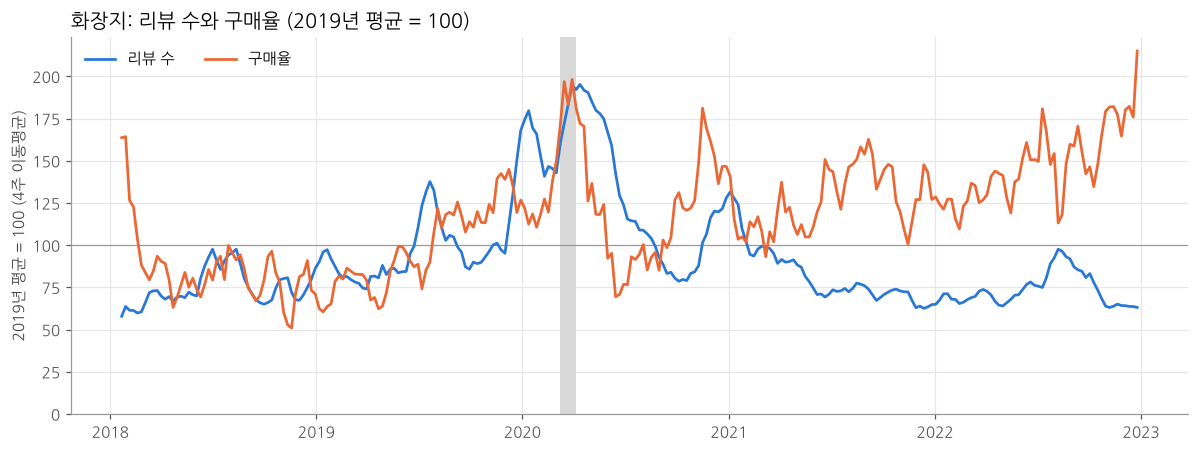

2019년 평균: {'review_count': 422.81, 'purchase_rate': 3.51}
2020-03-08 ~ 04-04 평균 (2019년 평균=100): {'review_count': 195.0, 'purchase_rate': 198.0}


In [3]:
tp = (rv[rv.product_type == "TOILET_PAPER"][["week", "review_count"]]
      .merge(pu[pu.product_type == "TOILET_PAPER"][["week", "purchase_rate"]], on="week", how="left")
      .sort_values("week").set_index("week"))
base = tp.loc["2019"].mean()
idx = (tp / base * 100).rolling(4, min_periods=4).mean()

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.axvspan(*SPIKE, color=GRAY, lw=0)
ax.axhline(100, color="#9a9a9a", lw=0.8)
ax.plot(idx.index, idx["review_count"], color=BLUE, lw=1.8, label="리뷰 수")
ax.plot(idx.index, idx["purchase_rate"], color=ORANGE, lw=1.8, label="구매율")
ax.set_ylim(0, None)
ax.set_ylabel("2019년 평균 = 100 (4주 이동평균)")
ax.xaxis.set_major_locator(mdates.YearLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left", frameon=False, ncol=2)
ax.set_title("화장지: 리뷰 수와 구매율 (2019년 평균 = 100)", loc="left", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "eda_toilet_paper_reviews_vs_purchase.png", bbox_inches="tight"); plt.show()

print("2019년 평균:", base.round(2).to_dict())
print("2020-03-08 ~ 04-04 평균 (2019년 평균=100):", (tp.loc["2020-03-08":"2020-04-04"].mean() / base * 100).round(0).to_dict())

## 4. 화장지: 급증기에 평점이 떨어졌나

- 평균 평점과 1점 비율은 단위가 달라서 **위아래 두 칸**으로 나눈다. 가로축(주)은 같이 쓴다.
- 2019~2021년만 그려 2020년 전후를 크게 본다.

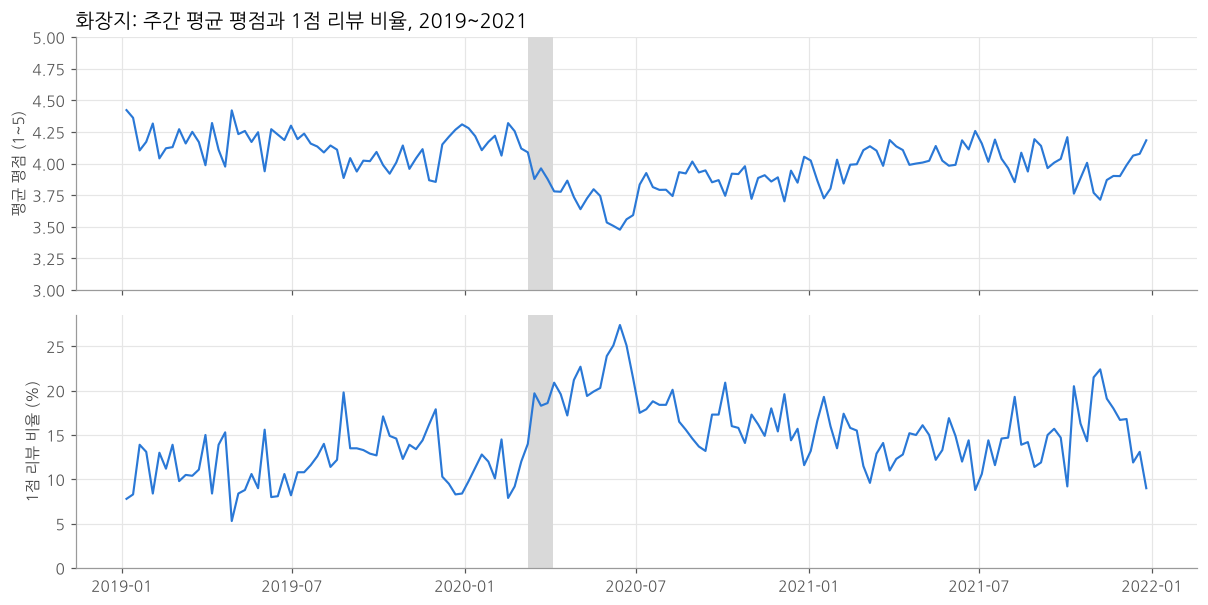

             기준 2019-03-10~04-06  급증 2020-03-08~04-04
avg_rating                 4.142                3.952
share_1star                0.118                0.176


In [4]:
d = rv[(rv.product_type == "TOILET_PAPER") & (rv.week >= "2019-01-01") & (rv.week < "2022-01-01")].set_index("week")
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.6), sharex=True)
for ax in (a1, a2): ax.axvspan(*SPIKE, color=GRAY, lw=0)
a1.plot(d.index, d["avg_rating"], color=BLUE, lw=1.4)
a1.set_ylabel("평균 평점 (1~5)"); a1.set_ylim(3, 5)
a2.plot(d.index, d["share_1star"] * 100, color=BLUE, lw=1.4)
a2.set_ylabel("1점 리뷰 비율 (%)"); a2.set_ylim(0, None)
a2.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])); a2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
a1.set_title("화장지: 주간 평균 평점과 1점 리뷰 비율, 2019~2021", loc="left", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "eda_toilet_paper_rating.png", bbox_inches="tight"); plt.show()

cmp = pd.DataFrame({
    "기준 2019-03-10~04-06": d.loc["2019-03-10":"2019-04-06", ["avg_rating", "share_1star"]].mean(),
    "급증 2020-03-08~04-04": d.loc["2020-03-08":"2020-04-04", ["avg_rating", "share_1star"]].mean()})
print(cmp.round(3))

## 5. 텍스트 정리: 무엇을 얼마나 고쳤나

- 03 노트북 출력값 (전체 1,107,639건 기준).
- **정리함**: 본문을 고친 것 (HTML 태그·특수문자 코드·URL). **표시만**: 지우지 않고 표시만 한 것 (표본 뽑을 때 제외).

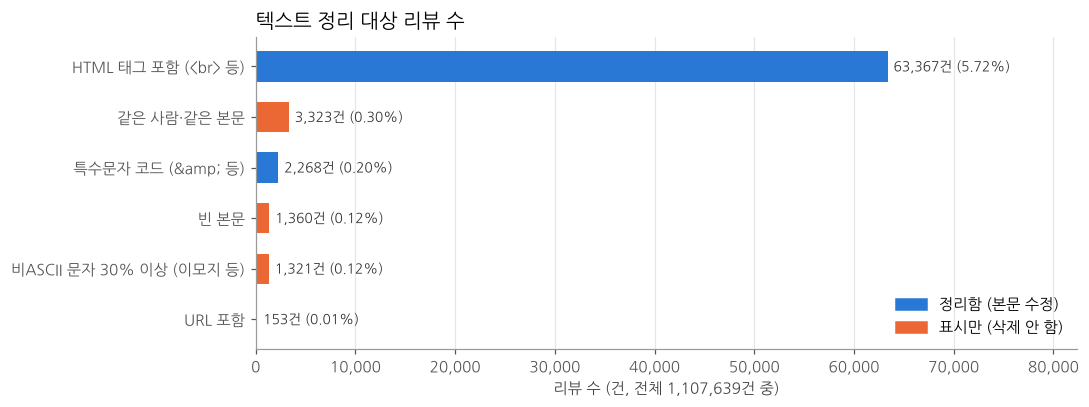

In [5]:
issues = pd.DataFrame([
    ("HTML 태그 포함 (<br> 등)", 63367, "정리함"),
    ("같은 사람·같은 본문", 3323, "표시만"),
    ("특수문자 코드 (&amp; 등)", 2268, "정리함"),
    ("빈 본문", 1360, "표시만"),
    ("비ASCII 문자 30% 이상 (이모지 등)", 1321, "표시만"),
    ("URL 포함", 153, "정리함"),
], columns=["항목", "건수", "처리"]).sort_values("건수")
fig, ax = plt.subplots(figsize=(10, 3.8))
colors = issues["처리"].map({"정리함": BLUE, "표시만": ORANGE})
ax.barh(issues["항목"], issues["건수"], color=colors, height=0.6)
for y, (v, h) in enumerate(zip(issues["건수"], issues["처리"])):
    ax.text(v + 600, y, f"{v:,}건 ({v / 1107639 * 100:.2f}%)", va="center", fontsize=9, color="#333333")
ax.set_xlim(0, issues["건수"].max() * 1.3); ax.grid(axis="y", visible=False)
ax.set_xlabel("리뷰 수 (건, 전체 1,107,639건 중)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="정리함 (본문 수정)"), Patch(color=ORANGE, label="표시만 (삭제 안 함)")],
          loc="lower right", frameon=False)
ax.set_title("텍스트 정리 대상 리뷰 수", loc="left", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "eda_text_cleaning_issues.png", bbox_inches="tight"); plt.show()

## 6. 품목별 리뷰 길이

- 03 노트북 출력값. 분석은 선행연구(Attri et al., 2025)처럼 **10~100단어** 리뷰만 쓴다.
- 보는 점: 품목마다 몇 %가 남는지, 화장지 리뷰는 왜 짧은지(중앙값 12단어).

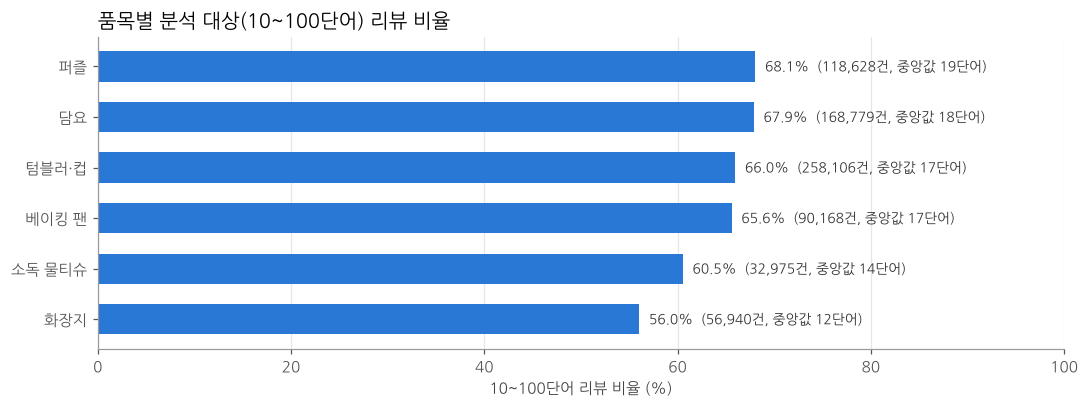

         product_type     리뷰  10~100단어  단어수_중앙값  단어수_상위10%  충족_비율
         TOILET_PAPER 101596     56940       12         53   56.0
SURFACE_CLEANING_WIPE  54464     32975       14         51   60.5
           BAKING_PAN 137451     90168       17         60   65.6
         DRINKING_CUP 391216    258106       17         60   66.0
              BLANKET 248588    168779       18         64   67.9
              PUZZLES 174324    118628       19         66   68.1


In [6]:
ln = pd.DataFrame({
    "product_type": ["BAKING_PAN", "BLANKET", "DRINKING_CUP", "PUZZLES", "SURFACE_CLEANING_WIPE", "TOILET_PAPER"],
    "리뷰": [137451, 248588, 391216, 174324, 54464, 101596],
    "10~100단어": [90168, 168779, 258106, 118628, 32975, 56940],
    "단어수_중앙값": [17, 18, 17, 19, 14, 12],
    "단어수_상위10%": [60, 64, 60, 66, 51, 53]})
ln["충족_비율"] = ln["10~100단어"] / ln["리뷰"] * 100
ln = ln.sort_values("충족_비율")
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.barh([KO[p] for p in ln["product_type"]], ln["충족_비율"], color=BLUE, height=0.6)
for y, r in enumerate(ln.itertuples()):
    ax.text(r.충족_비율 + 1, y, f"{r.충족_비율:.1f}%  ({r._3:,}건, 중앙값 {r.단어수_중앙값}단어)", va="center", fontsize=9, color="#333333")
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)
ax.set_xlabel("10~100단어 리뷰 비율 (%)")
ax.set_title("품목별 분석 대상(10~100단어) 리뷰 비율", loc="left", fontsize=13)
fig.tight_layout(); fig.savefig(FIG / "eda_review_length_by_type.png", bbox_inches="tight"); plt.show()
print(ln.round(1).to_string(index=False))